# GAN, EV-GAN, and Fixed-Level ExceedGAN

This notebook follows the public repository

`michael-allouche/extreme-value-GAN`

as closely as possible for the **model definitions, data generation, training loop, hyperparameters and simulation scheme**.

The comparison contains the repository's standard GAN, EV-GAN and Fixed-Level ExceedGAN.

> **Runtime warning.** The repository quick-start uses `N_EPOCHS = 5_000`. Running all three models at that setting can take a long time. The notebook deliberately keeps that value because the purpose of this version is fidelity to the GitHub implementation rather than speed.

## 1. Imports and reproducibility

The imports and global seeding follow `main.py`. The repository's base GAN selects CUDA when available and otherwise uses CPU.

In [1]:
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats as st
from scipy.special import expi
from statsmodels.distributions.copula.api import (
    CopulaDistribution,
    GumbelCopula
)

import torch
import torch.nn as nn
import torch.nn.functional as F


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 123
set_seed(SEED)

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


## 2. Repository hyperparameters

These are the values in the current `main.py`.

In [2]:
# Model hyperparameters from main.py
LATENT_DIM = 10
HIDDEN_DIM_G = [30]
HIDDEN_DIM_D = [10, 10]

LR_D = 1e-4
LR_G = 1e-4
NORMALIZATION = False

# Data hyperparameters from main.py
N_DATA = 50_000
DIM_DATA = 2
ANCHOR_LEVELS = [0.05] * DIM_DATA

GAMMA = 0.5
RHO = -1.0
THETA = 2.0

# Quick-start training settings from the README
N_EPOCHS = 5_000
BATCH_SIZE = 32
VERBOSE = 100
K_TRAIN_D = 1

## 3. Data helpers from the repository

`generate_data()` reproduces `main.py`: every margin is Burr XII with the **same** `gamma` and `rho`, coupled using a Gumbel copula.

`get_data_uqr()` follows `models/utils.py`, including the empirical order-statistic definition of the anchor points.

In [3]:
def generate_data(
    n_data: int,
    dim_data: int,
    theta: float,
    gamma: float,
    rho: float,
    seed: int = 123
) -> np.ndarray:

    marginals = [
        st.burr12(
            c=-rho / gamma,
            d=-1 / rho
        )
        for _ in range(dim_data)
    ]

    copula = CopulaDistribution(
        copula=GumbelCopula(
            theta=theta,
            k_dim=dim_data
        ),
        marginals=marginals
    )

    return copula.rvs(
        n_data,
        random_state=seed
    )


def get_data_uqr(X, anchor_levels):

    n_data = X.shape[0]

    anchor_points = np.array([
        np.sort(X[:, j])[
            np.maximum(
                0,
                int(
                    np.around(
                        (1 - anchor_levels[j]) * n_data
                    )
                ) - 1
            )
        ]
        for j in range(len(anchor_levels))
    ])

    X_uqr = X[
        np.all(
            [
                X[:, j] > anchor_points[j]
                for j in range(len(anchor_levels))
            ],
            axis=0
        )
    ]

    return X_uqr, anchor_points

In [4]:
trainset = generate_data(
    N_DATA,
    DIM_DATA,
    THETA,
    GAMMA,
    RHO,
    seed=SEED
)

trainset_excess, anchor_points = get_data_uqr(
    trainset,
    ANCHOR_LEVELS
)

print("Full training sample:", trainset.shape)
print("Upper-quadrant sample:", trainset_excess.shape)
print("Anchor points:", anchor_points)

Full training sample: (50000, 2)
Upper-quadrant sample: (1492, 2)
Anchor points: [4.42387541 4.36289466]


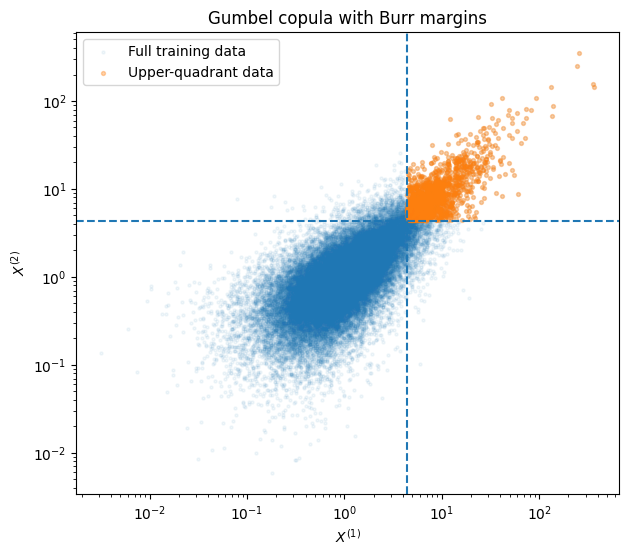

In [5]:
plt.figure(figsize=(7, 6))

plt.scatter(
    trainset[:, 0],
    trainset[:, 1],
    s=5,
    alpha=0.06,
    label="Full training data"
)

plt.scatter(
    trainset_excess[:, 0],
    trainset_excess[:, 1],
    s=8,
    alpha=0.35,
    label="Upper-quadrant data"
)

plt.axvline(anchor_points[0], linestyle="--")
plt.axhline(anchor_points[1], linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$X^{(1)}$")
plt.ylabel(r"$X^{(2)}$")
plt.legend()
plt.title("Gumbel copula with Burr margins")
plt.show()

## 4. Shared neural-network blocks

These reproduce `BlockReLU` and `BlockELU` from `models/utils.py`.

In [6]:
class BlockReLU(nn.Module):

    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return F.relu(self.fc(inputs))


class BlockELU(nn.Module):

    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)

    def forward(self, inputs):
        return F.elu(self.fc(inputs))

## 5. Standard GAN — repository architecture

The generator ends with a ReLU. The discriminator ends with a **Sigmoid** and returns one probability per data dimension.

This is important: the GitHub implementation uses ordinary binary cross entropy applied to probabilities, **not** `BCEWithLogitsLoss`.

In [7]:
class GANGenerator(nn.Module):

    def __init__(
        self,
        dim_data,
        latent_dim,
        hidden_dims
    ):
        super().__init__()

        self.dim_data = dim_data
        self.latent_dim = latent_dim
        self.hidden_dims = hidden_dims

        list_layers = []
        current_hdim = latent_dim

        for hidden_dim in hidden_dims:
            list_layers.append(
                BlockReLU(
                    current_hdim,
                    hidden_dim
                )
            )
            current_hdim = hidden_dim

        list_layers.append(
            nn.Linear(
                current_hdim,
                dim_data
            )
        )

        self.layers = nn.Sequential(
            *list_layers
        )

    def forward(self, inputs):
        return F.relu(
            self.layers(inputs)
        )


class GANDiscriminator(nn.Module):

    def __init__(
        self,
        dim_data,
        hidden_dims
    ):
        super().__init__()

        self.dim_data = dim_data
        self.hidden_dims = hidden_dims

        list_layers = []
        current_hdim = dim_data

        for hidden_dim in hidden_dims:
            list_layers.append(
                BlockReLU(
                    current_hdim,
                    hidden_dim
                )
            )
            current_hdim = hidden_dim

        list_layers.append(
            nn.Linear(
                current_hdim,
                dim_data
            )
        )

        list_layers.append(
            nn.Sigmoid()
        )

        self.layers = nn.Sequential(
            *list_layers
        )

    def forward(self, inputs):
        return self.layers(inputs)

## 6. Base GAN class — repository training and simulation scheme

This reproduces the logic of `models/gan.py`.

Training is **epoch based**. Within every mini-batch:

1. update the discriminator `k_train_D` times;
2. update the generator once;
3. use `torch.rand()` latent variables on $[0,1)^{d_Z}$;
4. use ordinary BCE on the discriminator's sigmoid probabilities.

The full input sample is passed to `train()`. The method itself computes the upper-quadrant data using `anchor_levels`.

For the standard GAN and EV-GAN, `simulate_excess()` uses acceptance–rejection until the requested number of upper-quadrant observations has been obtained.

In [8]:
class GAN(nn.Module):

    def __init__(
        self,
        dim_data,
        latent_dim,
        hidden_dims_G,
        hidden_dims_D,
        lrD=1e-3,
        lrG=1e-3,
        **kwargs
    ):
        super().__init__()

        torch.manual_seed(123)

        self.device = self.get_device()

        self.dim_data = dim_data
        self.latent_dim = latent_dim
        self.hidden_dims_G = hidden_dims_G
        self.hidden_dims_D = hidden_dims_D
        self.lrG = lrG
        self.lrD = lrD

        self.anchor_levels = None
        self.anchor_points = None

        self.Xmax = None
        self.normalization = None

        self.generator = GANGenerator(
            dim_data,
            latent_dim,
            hidden_dims_G
        ).to(self.device)

        self.discriminator = GANDiscriminator(
            dim_data,
            hidden_dims_D
        ).to(self.device)

        self.optimizerG = torch.optim.Adam(
            self.generator.parameters(),
            lr=lrG
        )

        self.optimizerD = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=lrD
        )

    def train(
        self,
        data_train,
        n_epochs,
        batch_size,
        verbose,
        anchor_levels=None,
        k_train_D=1,
        normalization=False
    ):

        self.generator.to(self.device)
        self.discriminator.to(self.device)

        self.Xmax = torch.tensor(
            data_train.max(axis=0),
            dtype=torch.float32,
            device=self.device
        )

        self.normalization = normalization

        if anchor_levels is None:
            self.anchor_levels = torch.zeros(
                self.dim_data,
                device=self.device,
                dtype=torch.float32
            )
        else:
            self.anchor_levels = torch.tensor(
                anchor_levels,
                dtype=torch.float32
            ).to(self.device)

        early_stopping = 0
        old_loss = 0

        if normalization:
            data_train = self.data_normalization(
                data_train
            )

        data_train, anchor_points = get_data_uqr(
            data_train,
            self.anchor_levels
        )

        self.anchor_points = torch.tensor(
            anchor_points,
            device=self.device,
            dtype=torch.float32
        )

        self.generator.anchor_points = self.anchor_points
        self.generator.anchor_levels = self.anchor_levels
        self.discriminator.anchor_levels = self.anchor_levels

        noise_valid = torch.rand(
            data_train.shape[0],
            self.latent_dim,
            device=self.device
        )

        while noise_valid.min() == 0:
            noise_valid = torch.rand(
                data_train.shape[0],
                self.latent_dim,
                device=self.device
            )

        trainset_loader = torch.utils.data.DataLoader(
            torch.tensor(
                data_train,
                dtype=torch.float32
            ),
            batch_size=batch_size,
            shuffle=True,
            worker_init_fn=lambda _: np.random.seed(0)
        )

        history_G = []
        history_D = []
        history_epoch = []

        try:
            for epoch in range(
                1,
                n_epochs + 1
            ):

                start_time = time.time()

                for X_train in trainset_loader:

                    X_train = X_train.to(
                        self.device
                    )

                    # ------------------------------------------
                    # Train discriminator
                    # ------------------------------------------
                    for _ in range(k_train_D):

                        noise = torch.rand(
                            batch_size,
                            self.latent_dim,
                            device=self.device
                        )

                        while noise.min() == 0:
                            noise = torch.rand(
                                batch_size,
                                self.latent_dim,
                                device=self.device
                            )

                        self.discriminator.zero_grad()

                        generated_data = self.generator(
                            noise
                        )

                        real_output = self.discriminator(
                            X_train
                        )

                        fake_output = self.discriminator(
                            generated_data
                        )

                        lossD = self.discriminator_loss(
                            real_output,
                            fake_output
                        )

                        lossD.backward()
                        self.optimizerD.step()

                    # ------------------------------------------
                    # Train generator
                    # ------------------------------------------
                    noise = torch.rand(
                        batch_size,
                        self.latent_dim,
                        device=self.device
                    )

                    while noise.min() == 0:
                        noise = torch.rand(
                            batch_size,
                            self.latent_dim,
                            device=self.device
                        )

                    generated_data = self.generator(
                        noise
                    )

                    fake_output = self.discriminator(
                        generated_data
                    )

                    self.generator.zero_grad()

                    lossG = self.generator_loss(
                        fake_output
                    )

                    lossG.backward()
                    self.optimizerG.step()

                if epoch % verbose == 0:

                    epoch_time = (
                        time.time() - start_time
                    )

                    lossG_value = float(
                        lossG.detach().cpu().numpy()
                    )

                    lossD_value = float(
                        lossD.detach().cpu().numpy()
                    )

                    history_epoch.append(epoch)
                    history_G.append(lossG_value)
                    history_D.append(lossD_value)

                    print(
                        "Epoch {} ({:.2f} sec): "
                        "Loss Generator={:.4f}, "
                        "Loss Discriminator={:.4f}".format(
                            epoch,
                            epoch_time,
                            lossG_value,
                            lossD_value
                        )
                    )

                    new_loss = (
                        np.round(
                            lossG.detach().cpu().numpy(),
                            8
                        )
                        +
                        np.round(
                            lossD.detach().cpu().numpy(),
                            8
                        )
                    )

                    if old_loss == new_loss:
                        early_stopping += 1

                        if early_stopping == verbose:
                            print(
                                "Early Stopping"
                            )
                            break
                    else:
                        early_stopping = 0

                    old_loss = new_loss

        except RuntimeError as e:
            print(
                "Runtime Error at epoch {}: {}".format(
                    epoch,
                    e
                )
            )
            return

        print("------ END TRAINING ------")

        self.history_epoch = history_epoch
        self.history_G = history_G
        self.history_D = history_D

    def discriminator_loss(
        self,
        real_output,
        fake_output
    ):

        real_loss = F.binary_cross_entropy(
            input=real_output,
            target=torch.ones_like(
                real_output,
                device=self.device
            )
        )

        fake_loss = F.binary_cross_entropy(
            input=fake_output,
            target=torch.zeros_like(
                fake_output,
                device=self.device
            )
        )

        return real_loss + fake_loss

    def generator_loss(
        self,
        fake_output
    ):

        return F.binary_cross_entropy(
            input=fake_output,
            target=torch.ones_like(
                fake_output,
                device=self.device
            )
        )

    def data_normalization(
        self,
        data
    ):
        return (
            data
            /
            self.Xmax.reshape(1, -1)
        )

    def inv_data_normalization(
        self,
        x
    ):
        return x * self.Xmax

    @torch.no_grad()
    def simulate(
        self,
        n_data,
        noise=None,
        seed=0
    ):

        if noise is None:

            torch.manual_seed(seed)

            noise = torch.rand(
                (
                    n_data,
                    self.latent_dim
                ),
                device=self.device
            )

            while noise.min() == 0:
                noise = torch.rand(
                    (
                        n_data,
                        self.latent_dim
                    ),
                    device=self.device
                )

        if self.normalization:
            return (
                self.generator(noise).cpu()
                *
                self.Xmax
            )
        else:
            return self.generator(
                noise
            ).cpu()

    @torch.no_grad()
    def simulate_excess(
        self,
        n_data,
        noise=None,
        seed=0,
        **kwargs
    ):

        if kwargs:
            warnings.warn(
                "simulate_excess is using the anchor "
                "levels and the anchor points defined "
                "in the model"
            )

        n_simulated_points = n_data

        if noise is None:

            torch.manual_seed(seed)

            noise = torch.rand(
                (
                    n_data,
                    self.latent_dim
                ),
                device=self.device
            )

            while noise.min() == 0:
                noise = torch.rand(
                    (
                        n_data,
                        self.latent_dim
                    ),
                    device=self.device
                )

        X = self.generator(
            noise
        ).cpu()

        X_excess = X[
            np.all(
                [
                    X[:, d]
                    >
                    self.anchor_points[d]
                    for d
                    in range(
                        len(
                            self.anchor_points
                        )
                    )
                ],
                axis=0
            )
        ]

        while X_excess.shape[0] < n_data:

            n_rejected = (
                n_data
                -
                X_excess.shape[0]
            )

            n_simulated_points += (
                n_rejected
            )

            noise = torch.rand(
                (
                    n_rejected,
                    self.latent_dim
                ),
                device=self.device
            )

            while noise.min() == 0:
                noise = torch.rand(
                    (
                        n_rejected,
                        self.latent_dim
                    ),
                    device=self.device
                )

            X = self.generator(
                noise
            ).cpu()

            X_excess = torch.cat(
                [
                    X_excess,
                    X[
                        np.all(
                            [
                                X[:, d]
                                >
                                self.anchor_points[d]
                                for d
                                in range(
                                    len(
                                        self.anchor_points
                                    )
                                )
                            ],
                            axis=0
                        )
                    ]
                ]
            )

        X_out = X_excess[:n_data]

        if self.normalization:
            return X_out * self.Xmax
        else:
            return X_out

    @staticmethod
    def get_device() -> torch.device:

        if torch.cuda.is_available():
            return torch.device(
                "cuda:0"
            )
        else:
            return torch.device(
                "cpu"
            )

## 7. EV-GAN — repository generator

This is the current `models/evgan.py` parametrisation, including the six random learnable correction parameters, the SciPy logarithmic-integral calculation, the final ReLU on the corrected TIF, and the inverse-TIF activation.

In [9]:
class TIFinv(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(
        self,
        inputs,
        x
    ):
        return torch.pow(
            (1.0 -inputs.pow(2))
            /
            2,
            -x
        )


class EVGANGenerator(nn.Module):

    def __init__(
        self,
        dim_data,
        latent_dim,
        hidden_dims,
        device
    ):
        super().__init__()

        self.dim_data = dim_data
        self.latent_dim = latent_dim
        self.hidden_dims = hidden_dims
        self.device = device

        self.activation_TIF = TIFinv()

        list_layers = []
        current_hdim = latent_dim

        for hidden_dim in hidden_dims:
            list_layers.append(
                BlockReLU(
                    current_hdim,
                    hidden_dim
                )
            )
            current_hdim = hidden_dim

        list_layers.append(
            nn.Linear(
                current_hdim,
                dim_data
            )
        )

        self.layers = nn.Sequential(
            *list_layers
        )

        self.var1 = nn.Parameter(
            torch.randn(
                1,
                self.dim_data
            ),
            requires_grad=True
        )

        self.var2 = nn.Parameter(
            torch.randn(
                1,
                self.dim_data
            ),
            requires_grad=True
        )

        self.var3 = nn.Parameter(
            torch.randn(
                1,
                self.dim_data
            ),
            requires_grad=True
        )

        self.var4 = nn.Parameter(
            torch.randn(
                1,
                self.dim_data
            ),
            requires_grad=True
        )

        self.var5 = nn.Parameter(
            torch.randn(
                1,
                self.dim_data
            ),
            requires_grad=True
        )

        self.var6 = nn.Parameter(
            torch.randn(
                1,
                self.dim_data
            ),
            requires_grad=True
        )

    def spline01(
        self,
        inputs
    ):
        return (
            -4 * inputs**5
            +
            5 * inputs**4
        )

    def spline00(
        self,
        inputs
    ):
        return (
            inputs**3
            -
            2 * inputs**2
            +
            inputs
        )

    def correction_tif_1(
        self,
        inputs
    ):

        correction = (
            self.spline01(inputs)
            *
            (
                self.var1
                +
                self.Phi(inputs)
            )
        )

        correction = torch.nan_to_num(
            correction,
            nan=0.0
        )

        return correction

    def correction_tif_2(
        self,
        inputs
    ):
        return (
            self.var6
            *
            self.spline00(inputs)
        )

    def Phi(
        self,
        inputs
    ):

        log_term = torch.log(
            1.0 - inputs
        )

        li_term = self.li(
            1.0 - inputs
        )

        term1 = (
            self.var2
            /
            log_term
        )

        term2 = (
            self.var3
            *
            li_term
        )

        term3 = (
            self.var4
            *
            (
                (
                    1.0 - inputs
                )
                /
                log_term
                -
                li_term
            )
        )

        term4 = (
            self.var5
            *
            (
                (
                    (
                        1.0 - inputs
                    )
                    *
                    (
                        log_term
                        +
                        1
                    )
                )
                /
                (
                    2
                    *
                    log_term**2
                )
                -
                li_term / 2
            )
        )

        return (
            term1
            +
            term2
            +
            term3
            +
            term4
        )

    def li(
        self,
        inputs
    ):

        x = expi(
            torch.log(
                inputs
            ).cpu().numpy()
        )

        return torch.tensor(
            x
        ).to(
            self.device
        )

    def forward(
        self,
        inputs
    ):

        network = self.layers(
            inputs
        )

        tif_corr_1 = (
            self.correction_tif_1(
                inputs[
                    :,
                    :self.dim_data
                ]
            )
        )

        tif_corr_2 = (
            self.correction_tif_2(
                inputs[
                    :,
                    :self.dim_data
                ]
            )
        )

        network_tif = F.relu(
            network
            +
            tif_corr_1
            +
            tif_corr_2
        )

        return self.activation_TIF(
            inputs[
                :,
                :self.dim_data
            ],
            network_tif
        )


class EVGAN(GAN):

    def __init__(
        self,
        dim_data,
        latent_dim,
        hidden_dims_G,
        hidden_dims_D,
        lrD=1e-3,
        lrG=1e-3,
        **kwargs
    ):

        super().__init__(
            dim_data,
            latent_dim,
            hidden_dims_G,
            hidden_dims_D,
            float(lrD),
            float(lrG),
            **kwargs
        )

        torch.manual_seed(123)

        self.generator = EVGANGenerator(
            dim_data,
            latent_dim,
            hidden_dims_G,
            self.device
        ).to(
            self.device
        )

        self.optimizerG = torch.optim.Adam(
            self.generator.parameters(),
            lr=float(lrG)
        )

## 8. Fixed-Level ExceedGAN — repository generator and discriminator

This reproduces `models/fl_exceed_gan.py`. The generator concatenates the latent uniforms and the fixed anchor levels, applies `-log`, passes the result through eLU hidden layers, and returns

$$
\widehat u_n\odot
\exp\{\operatorname{ReLU}(N_\theta)\}.
$$

The anchor levels and empirical anchor points are populated by the inherited `train()` method before the first mini-batch is processed.

In [10]:
class FLExceedGenerator(nn.Module):

    def __init__(
        self,
        dim_data,
        latent_dim,
        hidden_dims,
        anchor_levels,
        anchor_points,
        device
    ):
        super().__init__()

        self.dim_data = dim_data
        self.latent_dim = latent_dim
        self.hidden_dims = hidden_dims
        self.anchor_levels = anchor_levels
        self.anchor_points = anchor_points
        self.device = device

        list_layers = []
        current_hdim = (
            latent_dim
            +
            self.dim_data
        )

        for hidden_dim in hidden_dims:
            list_layers.append(
                BlockELU(
                    current_hdim,
                    hidden_dim
                )
            )
            current_hdim = hidden_dim

        list_layers.append(
            nn.Linear(
                current_hdim,
                self.dim_data
            )
        )

        self.layers = nn.Sequential(
            *list_layers
        )

    def forward(
        self,
        inputs
    ):

        u = (
            torch.ones(
                inputs.shape[0],
                self.dim_data,
                device=self.device
            )
            *
            self.anchor_levels
        )

        network = self.layers(
            -torch.log(
                torch.cat(
                    [
                        inputs,
                        u
                    ],
                    dim=1
                )
            )
        )

        return (
            self.anchor_points
            *
            torch.exp(
                F.relu(
                    network
                )
            )
        )


class FLExceedDiscriminator(nn.Module):

    def __init__(
        self,
        dim_data,
        hidden_dims,
        device
    ):
        super().__init__()

        self.dim_data = dim_data
        self.hidden_dims = hidden_dims
        self.device = device

        list_layers = []
        current_hdim = dim_data

        for hidden_dim in hidden_dims:
            list_layers.append(
                BlockReLU(
                    current_hdim,
                    hidden_dim
                )
            )
            current_hdim = hidden_dim

        list_layers.append(
            nn.Linear(
                current_hdim,
                self.dim_data
            )
        )

        list_layers.append(
            nn.Sigmoid()
        )

        self.layers = nn.Sequential(
            *list_layers
        )

    def forward(
        self,
        inputs
    ):
        return self.layers(inputs)


class FLExceedGAN(GAN):

    def __init__(
        self,
        dim_data,
        latent_dim,
        hidden_dims_G,
        hidden_dims_D,
        lrD=1e-3,
        lrG=1e-3,
        **kwargs
    ):

        super().__init__(
            dim_data,
            latent_dim,
            hidden_dims_G,
            hidden_dims_D,
            float(lrD),
            float(lrG),
            **kwargs
        )

        torch.manual_seed(123)

        self.anchor_levels = None
        self.anchor_points = None

        self.generator = FLExceedGenerator(
            dim_data,
            latent_dim,
            hidden_dims_G,
            self.anchor_levels,
            self.anchor_points,
            self.device
        ).to(
            self.device
        )

        self.discriminator = FLExceedDiscriminator(
            dim_data,
            hidden_dims_D,
            self.device
        ).to(
            self.device
        )

        self.optimizerG = torch.optim.Adam(
            self.generator.parameters(),
            lr=float(lrG)
        )

        self.optimizerD = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=float(lrD)
        )

# 9. Train the standard GAN

This is equivalent to running the repository with

```bash
python main.py --model gan --n_epochs 5000 --batch_size 32 --verbose 100
```

The full `trainset` is supplied to `model.train()`. The model itself filters the upper-quadrant observations.

In [11]:
set_seed(SEED)

model_gan = GAN(
    DIM_DATA,
    LATENT_DIM,
    HIDDEN_DIM_G,
    HIDDEN_DIM_D,
    lrD=LR_D,
    lrG=LR_G
)

model_gan.train(
    trainset,
    N_EPOCHS,
    BATCH_SIZE,
    VERBOSE,
    anchor_levels=ANCHOR_LEVELS,
    k_train_D=K_TRAIN_D,
    normalization=NORMALIZATION
)

Epoch 100 (0.08 sec): Loss Generator=0.6535, Loss Discriminator=1.4845
Epoch 200 (0.07 sec): Loss Generator=0.8780, Loss Discriminator=0.9075
Epoch 300 (0.07 sec): Loss Generator=0.8129, Loss Discriminator=1.3940
Epoch 400 (0.07 sec): Loss Generator=0.6485, Loss Discriminator=1.4875
Epoch 500 (0.07 sec): Loss Generator=0.6460, Loss Discriminator=1.6397
Epoch 600 (0.07 sec): Loss Generator=0.6926, Loss Discriminator=1.2687
Epoch 700 (0.08 sec): Loss Generator=0.8018, Loss Discriminator=1.2819
Epoch 800 (0.09 sec): Loss Generator=0.6977, Loss Discriminator=1.3807
Epoch 900 (0.08 sec): Loss Generator=0.6981, Loss Discriminator=1.3671
Epoch 1000 (0.09 sec): Loss Generator=0.7658, Loss Discriminator=1.2176
Epoch 1100 (0.08 sec): Loss Generator=0.8204, Loss Discriminator=1.2341
Epoch 1200 (0.12 sec): Loss Generator=0.7381, Loss Discriminator=1.1089
Epoch 1300 (0.09 sec): Loss Generator=0.7383, Loss Discriminator=1.2386
Epoch 1400 (0.10 sec): Loss Generator=0.7177, Loss Discriminator=1.2959
E

# 10. Train EV-GAN

The training loop is unchanged; only the generator parametrisation differs.

In [12]:
set_seed(SEED)

model_evgan = EVGAN(
    DIM_DATA,
    LATENT_DIM,
    HIDDEN_DIM_G,
    HIDDEN_DIM_D,
    lrD=LR_D,
    lrG=LR_G
)

model_evgan.train(
    trainset,
    N_EPOCHS,
    BATCH_SIZE,
    VERBOSE,
    anchor_levels=ANCHOR_LEVELS,
    k_train_D=K_TRAIN_D,
    normalization=NORMALIZATION
)

Epoch 100 (0.14 sec): Loss Generator=1.4021, Loss Discriminator=0.4552
Epoch 200 (0.15 sec): Loss Generator=1.3677, Loss Discriminator=1.0958
Epoch 300 (0.12 sec): Loss Generator=0.8524, Loss Discriminator=1.2063
Epoch 400 (0.15 sec): Loss Generator=0.7326, Loss Discriminator=1.3455
Epoch 500 (0.17 sec): Loss Generator=0.7913, Loss Discriminator=1.3941
Epoch 600 (0.13 sec): Loss Generator=0.7231, Loss Discriminator=1.3541
Epoch 700 (0.15 sec): Loss Generator=0.7166, Loss Discriminator=1.3881
Epoch 800 (0.13 sec): Loss Generator=0.7224, Loss Discriminator=1.3177
Epoch 900 (0.12 sec): Loss Generator=0.7176, Loss Discriminator=1.3580
Epoch 1000 (0.13 sec): Loss Generator=0.7299, Loss Discriminator=1.3664
Epoch 1100 (0.14 sec): Loss Generator=0.7199, Loss Discriminator=1.4096
Epoch 1200 (0.26 sec): Loss Generator=0.7680, Loss Discriminator=1.3299
Epoch 1300 (0.15 sec): Loss Generator=0.7108, Loss Discriminator=1.3638
Epoch 1400 (0.13 sec): Loss Generator=0.7229, Loss Discriminator=1.3704
E

# 11. Train Fixed-Level ExceedGAN

Again, the same inherited training loop is used. The generator and discriminator are those from `fl_exceed_gan.py`.

In [13]:
set_seed(SEED)

model_exceed = FLExceedGAN(
    DIM_DATA,
    LATENT_DIM,
    HIDDEN_DIM_G,
    HIDDEN_DIM_D,
    lrD=LR_D,
    lrG=LR_G
)

model_exceed.train(
    trainset,
    N_EPOCHS,
    BATCH_SIZE,
    VERBOSE,
    anchor_levels=ANCHOR_LEVELS,
    k_train_D=K_TRAIN_D,
    normalization=NORMALIZATION
)

Epoch 100 (0.08 sec): Loss Generator=0.7230, Loss Discriminator=1.3780
Epoch 200 (0.09 sec): Loss Generator=0.6968, Loss Discriminator=1.3884
Epoch 300 (0.08 sec): Loss Generator=0.6877, Loss Discriminator=1.3911
Epoch 400 (0.09 sec): Loss Generator=0.6778, Loss Discriminator=1.3779
Epoch 500 (0.10 sec): Loss Generator=0.6935, Loss Discriminator=1.3891
Epoch 600 (0.10 sec): Loss Generator=0.6815, Loss Discriminator=1.3743
Epoch 700 (0.08 sec): Loss Generator=0.6925, Loss Discriminator=1.3988
Epoch 800 (0.10 sec): Loss Generator=0.7002, Loss Discriminator=1.3951
Epoch 900 (0.09 sec): Loss Generator=0.6846, Loss Discriminator=1.3994
Epoch 1000 (0.10 sec): Loss Generator=0.6904, Loss Discriminator=1.3767
Epoch 1100 (0.09 sec): Loss Generator=0.6974, Loss Discriminator=1.3920
Epoch 1200 (0.08 sec): Loss Generator=0.6964, Loss Discriminator=1.3811
Epoch 1300 (0.08 sec): Loss Generator=0.6930, Loss Discriminator=1.3978
Epoch 1400 (0.10 sec): Loss Generator=0.6867, Loss Discriminator=1.3841
E

# 12. Simulate excesses using the repository scheme

The repository's `main.py` calls `simulate_excess()` after training.

For the standard GAN and EV-GAN this performs acceptance–rejection. For FL-ExceedGAN the architecture already places generated observations above the fitted anchors, so acceptance is effectively immediate unless a generated coordinate equals an anchor exactly.

In [14]:
N_COMPARE = len(trainset_excess)

with torch.no_grad():

    X_gan = model_gan.simulate_excess(
        n_data=N_COMPARE,
        anchor_levels=ANCHOR_LEVELS,
        anchor_points=anchor_points
    ).numpy()

    X_evgan = model_evgan.simulate_excess(
        n_data=N_COMPARE,
        anchor_levels=ANCHOR_LEVELS,
        anchor_points=anchor_points
    ).numpy()

    X_exceed = model_exceed.simulate_excess(
        n_data=N_COMPARE,
        anchor_levels=ANCHOR_LEVELS,
        anchor_points=anchor_points
    ).numpy()

print("Generated GAN:", X_gan.shape)
print("Generated EV-GAN:", X_evgan.shape)
print("Generated FL-ExceedGAN:", X_exceed.shape)

Generated GAN: (1492, 2)
Generated EV-GAN: (1492, 2)
Generated FL-ExceedGAN: (1492, 2)


/var/folders/t4/7gn5krc96gs3qph3d6r331ym0000gn/T/ipykernel_65675/734865344.py:396: UserWarning: simulate_excess is using the anchor levels and the anchor points defined in the model
  warnings.warn(


# 13. GitHub-style visual comparison

The original repository plots the training data, observed upper-quadrant data and generated excesses together. Here we show one panel for each model and use log-log axes so that tail coverage is easier to inspect.

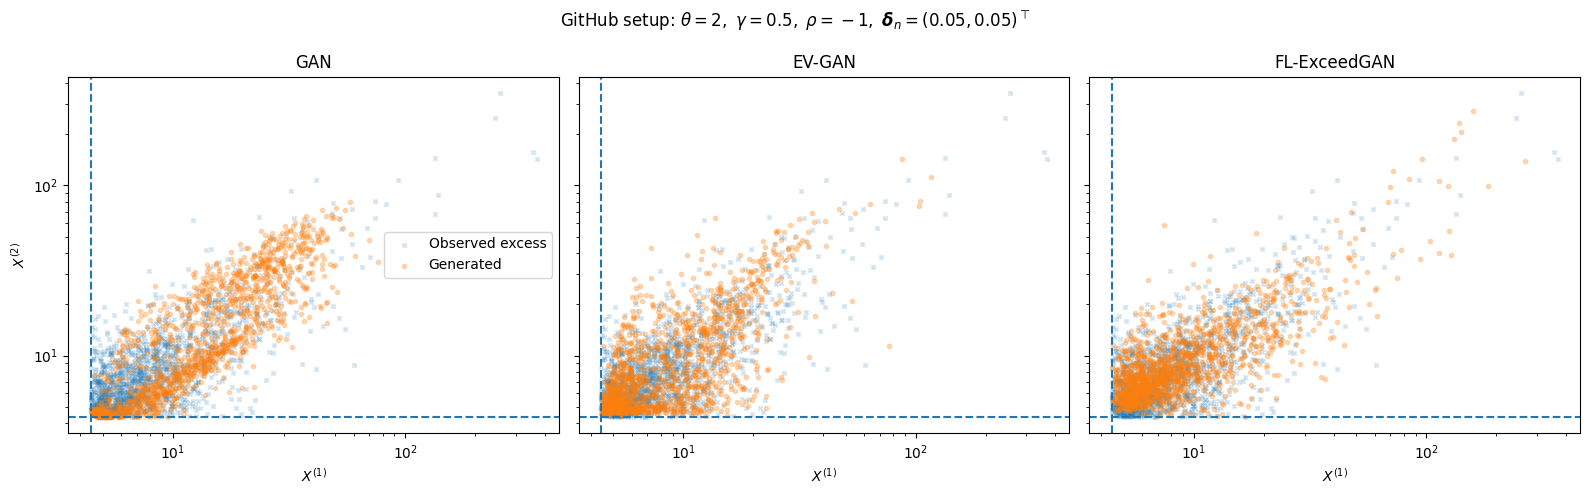

In [15]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    sharex=True,
    sharey=True
)

for ax, (name, X_sim) in zip(
    axes,
    [
        ("GAN", X_gan),
        ("EV-GAN", X_evgan),
        ("FL-ExceedGAN", X_exceed)
    ]
):

    ax.scatter(
        trainset_excess[:, 0],
        trainset_excess[:, 1],
        s=9,
        alpha=0.20,
        marker="x",
        label="Observed excess"
    )

    ax.scatter(
        X_sim[:, 0],
        X_sim[:, 1],
        s=9,
        alpha=0.28,
        label="Generated"
    )

    ax.axvline(
        anchor_points[0],
        linestyle="--"
    )

    ax.axhline(
        anchor_points[1],
        linestyle="--"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$X^{(1)}$")
    ax.set_title(name)

axes[0].set_ylabel(r"$X^{(2)}$")
axes[0].legend()

plt.suptitle(
    r"GitHub setup: "
    r"$\theta=2,\ \gamma=0.5,\ \rho=-1,\ "
    r"\boldsymbol{\delta}_n=(0.05,0.05)^\top$"
)

plt.tight_layout()
plt.show()

# 14. Quantifying the fitted dependence structure

A visual scatter plot can hide substantial differences in dependence. We therefore compare the observed and generated excess distributions using several complementary summaries.

All diagnostics below are calculated **within the upper-quadrant distribution** being learned by the GANs. We report Kendall's $\tau$, Spearman's $\rho$, Pearson correlation of the log-excess ratios, and a rank-based upper-tail dependence curve

$$
\chi(q)=\Pr(U_2>q\mid U_1>q),
$$

where $U_1,U_2$ are empirical probability-integral transforms within the conditional excess distribution.

In [16]:
def pseudo_observations(X):
    X = np.asarray(X)
    U = np.empty_like(X, dtype=float)
    n = len(X)
    for j in range(X.shape[1]):
        U[:, j] = st.rankdata(X[:, j], method="average") / (n + 1.0)
    return U


def dependence_summary(X, name):
    X = np.asarray(X)
    tau = st.kendalltau(X[:, 0], X[:, 1]).statistic
    spear = st.spearmanr(X[:, 0], X[:, 1]).statistic
    log_ratio = np.log(np.maximum(X / anchor_points.reshape(1, -1), 1e-12))
    log_corr = np.corrcoef(log_ratio[:, 0], log_ratio[:, 1])[0, 1]
    return {
        "Model": name,
        "Kendall tau": tau,
        "Spearman rho": spear,
        "Corr(log excess)": log_corr
    }


def chi_curve(X, q_grid):
    U = pseudo_observations(X)
    out = []
    for q in q_grid:
        mask_1 = U[:, 0] > q
        out.append(np.nan if mask_1.sum() == 0 else np.mean(U[mask_1, 1] > q))
    return np.asarray(out)


dependence_table = pd.DataFrame([
    dependence_summary(trainset_excess, "Observed excess"),
    dependence_summary(X_gan, "GAN"),
    dependence_summary(X_evgan, "EV-GAN"),
    dependence_summary(X_exceed, "FL-ExceedGAN")
])

dependence_table

,Model,Kendall tau,Spearman rho,Corr(log excess)
0,Observed excess,0.433011,0.599904,0.748515
1,GAN,0.700316,0.887901,0.880562
2,EV-GAN,0.464886,0.645677,0.715986
3,FL-ExceedGAN,0.474186,0.648947,0.779484


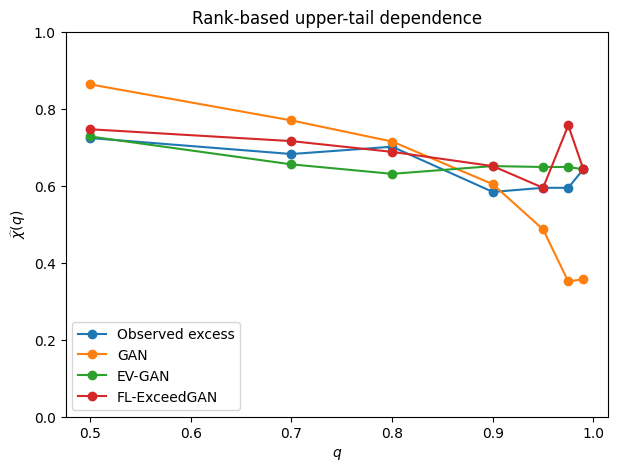

In [17]:
q_grid = np.array([0.50, 0.70, 0.80, 0.90, 0.95, 0.975, 0.99])

plt.figure(figsize=(7, 5))
for name, X in [
    ("Observed excess", trainset_excess),
    ("GAN", X_gan),
    ("EV-GAN", X_evgan),
    ("FL-ExceedGAN", X_exceed)
]:
    plt.plot(q_grid, chi_curve(X, q_grid), marker="o", label=name)

plt.xlabel(r"$q$")
plt.ylabel(r"$\widehat{\chi}(q)$")
plt.title("Rank-based upper-tail dependence")
plt.ylim(0, 1)
plt.legend()
plt.show()

# 15. Angular-radial diagnostics for extreme dependence

For positive upper-quadrant observations, define the log-excess coordinates

$$
E_m=\log\left(\frac{X^{(m)}}{\widehat u_n^{(m)}}\right),\qquad m=1,2,
$$

and then

$$
R=E_1+E_2,\qquad W=\frac{E_1}{E_1+E_2}.
$$

$R$ measures the magnitude of the excursion beyond the fitted threshold, while $W$ describes its direction. Values of $W$ near $1/2$ indicate balanced bivariate extremes; values close to 0 or 1 indicate an event dominated by one margin.

The diagnostics below condition on the largest 20% of $R$ values in each sample.

In [18]:
def angular_radial(X, radial_quantile=0.80):
    X = np.asarray(X)
    E = np.log(np.maximum(X / anchor_points.reshape(1, -1), 1.0))
    R = E.sum(axis=1)
    good = R > 1e-12
    E = E[good]
    R = R[good]
    W = E[:, 0] / R
    cutoff = np.quantile(R, radial_quantile)
    keep = R >= cutoff
    return R[keep], W[keep]


def angular_summary(X, name):
    R, W = angular_radial(X)
    return {
        "Model": name,
        "Mean W": np.mean(W),
        "SD W": np.std(W),
        "P(0.4 < W < 0.6)": np.mean((W > 0.4) & (W < 0.6)),
        "P(W < 0.1 or W > 0.9)": np.mean((W < 0.1) | (W > 0.9)),
        "Median R": np.median(R)
    }


angular_table = pd.DataFrame([
    angular_summary(trainset_excess, "Observed excess"),
    angular_summary(X_gan, "GAN"),
    angular_summary(X_evgan, "EV-GAN"),
    angular_summary(X_exceed, "FL-ExceedGAN")
])

angular_table

,Model,Mean W,SD W,P(0.4 < W < 0.6),P(W < 0.1 or W > 0.9),Median R
0,Observed excess,0.498367,0.088649,0.785953,0.0,2.813011
1,GAN,0.477592,0.044365,0.959866,0.0,3.945666
2,EV-GAN,0.466382,0.082649,0.816054,0.0,2.840512
3,FL-ExceedGAN,0.523506,0.085624,0.779264,0.0,2.862147


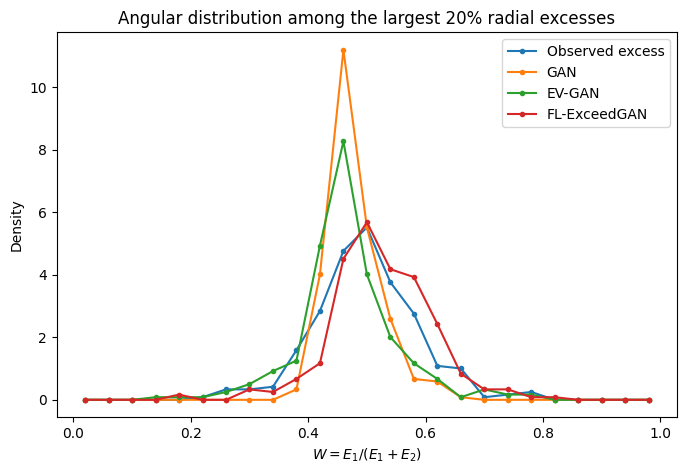

In [19]:
plt.figure(figsize=(8, 5))
bins = np.linspace(0, 1, 26)

for name, X in [
    ("Observed excess", trainset_excess),
    ("GAN", X_gan),
    ("EV-GAN", X_evgan),
    ("FL-ExceedGAN", X_exceed)
]:
    _, W = angular_radial(X)
    hist, edges = np.histogram(W, bins=bins, density=True)
    centres = (edges[:-1] + edges[1:]) / 2
    plt.plot(centres, hist, marker="o", markersize=3, label=name)

plt.xlabel(r"$W=E_1/(E_1+E_2)$")
plt.ylabel("Density")
plt.title("Angular distribution among the largest 20% radial excesses")
plt.legend()
plt.show()

# 16. Bivariate extrapolation beyond the training threshold

To assess genuine **bivariate extrapolation**, define for scale factors $s_1,s_2\geq1$

$$
S(s_1,s_2)=\Pr\left[X^{(1)}>s_1\widehat u_n^{(1)},\ X^{(2)}>s_2\widehat u_n^{(2)}\mid X\in\mathcal Q(\boldsymbol\delta_n)\right].
$$

An independent Monte Carlo sample from the known Gumbel-Burr model is used as the reference. It is not used for fitting. We inspect the diagonal curve $S(s,s)$ and the full two-dimensional surface $S(s_1,s_2)$.

In [20]:
# Independent truth sample for diagnostics only.
N_TRUTH_FULL = 250_000

truth_full = generate_data(
    N_TRUTH_FULL,
    DIM_DATA,
    THETA,
    GAMMA,
    RHO,
    seed=SEED + 10_000
)

truth_mask = np.all(
    truth_full > anchor_points.reshape(1, -1),
    axis=1
)
truth_excess = truth_full[truth_mask]

print("Independent truth excess sample:", truth_excess.shape)

Independent truth excess sample: (7406, 2)


In [21]:
def diagonal_joint_survival(X, scales, anchors=anchor_points):
    X = np.asarray(X)
    return np.array([
        np.mean(np.all(X > s * anchors.reshape(1, -1), axis=1))
        for s in scales
    ])


scales_diag = np.array([1.0, 1.10, 1.25, 1.50, 1.75, 2.0, 2.5, 3.0, 4.0])

survival_diag = {
    "Truth": diagonal_joint_survival(truth_excess, scales_diag),
    "GAN": diagonal_joint_survival(X_gan, scales_diag),
    "EV-GAN": diagonal_joint_survival(X_evgan, scales_diag),
    "FL-ExceedGAN": diagonal_joint_survival(X_exceed, scales_diag)
}

diag_table = pd.DataFrame({"Scale": scales_diag, **survival_diag})
diag_table

,Scale,Truth,GAN,EV-GAN,FL-ExceedGAN
0,1.00,1.000000,1.000000,1.000000,1.000000
1,1.10,0.823521,0.781501,0.802279,0.938338
2,1.25,0.635971,0.721180,0.558311,0.766756
3,1.50,0.444504,0.626005,0.396783,0.525469
4,1.75,0.323521,0.570375,0.327748,0.388070
5,2.00,0.246557,0.504021,0.272118,0.301609
6,2.50,0.156630,0.412869,0.197721,0.199062
7,3.00,0.109101,0.344504,0.148123,0.137399
8,4.00,0.059141,0.247989,0.075737,0.081099


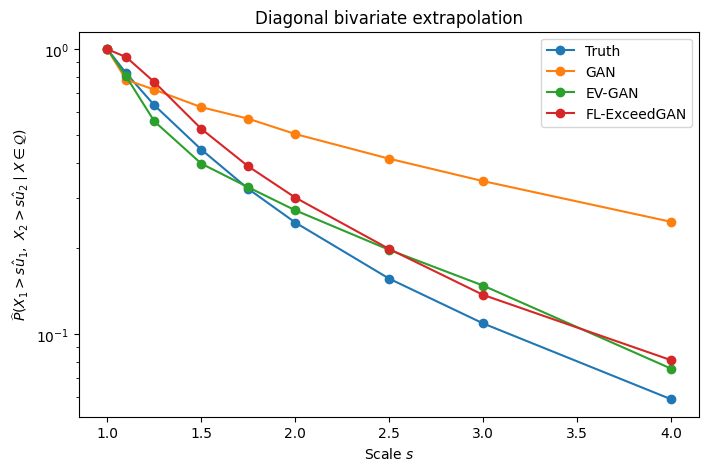

In [22]:
plt.figure(figsize=(8, 5))
for name, probs in survival_diag.items():
    plt.plot(scales_diag, np.maximum(probs, 1e-6), marker="o", label=name)

plt.yscale("log")
plt.xlabel(r"Scale $s$")
plt.ylabel(r"$\widehat{P}(X_1>s\hat u_1,\ X_2>s\hat u_2\mid X\in\mathcal{Q})$")
plt.title("Diagonal bivariate extrapolation")
plt.legend()
plt.show()

In [23]:
def joint_survival_surface(X, scale_grid, anchors=anchor_points):
    X = np.asarray(X)
    out = np.empty((len(scale_grid), len(scale_grid)))
    for i, s1 in enumerate(scale_grid):
        for j, s2 in enumerate(scale_grid):
            threshold = anchors * np.array([s1, s2])
            out[i, j] = np.mean(np.all(X > threshold.reshape(1, -1), axis=1))
    return out


scale_grid = np.linspace(1.0, 3.0, 13)

surface_truth = joint_survival_surface(truth_excess, scale_grid)
surface_gan = joint_survival_surface(X_gan, scale_grid)
surface_evgan = joint_survival_surface(X_evgan, scale_grid)
surface_exceed = joint_survival_surface(X_exceed, scale_grid)


def log_survival_rmse(truth, fitted, n_reference):
    min_prob = 5.0 / n_reference
    keep = truth >= min_prob
    if not np.any(keep):
        return np.nan
    truth_use = np.maximum(truth[keep], min_prob)
    fitted_use = np.maximum(fitted[keep], min_prob)
    return np.sqrt(np.mean((np.log10(fitted_use) - np.log10(truth_use))**2))


surface_error_table = pd.DataFrame({
    "Model": ["GAN", "EV-GAN", "FL-ExceedGAN"],
    "RMSE log10 joint survival": [
        log_survival_rmse(surface_truth, surface_gan, len(truth_excess)),
        log_survival_rmse(surface_truth, surface_evgan, len(truth_excess)),
        log_survival_rmse(surface_truth, surface_exceed, len(truth_excess))
    ]
})

surface_error_table

,Model,RMSE log10 joint survival
0,GAN,0.338512
1,EV-GAN,0.080554
2,FL-ExceedGAN,0.078961


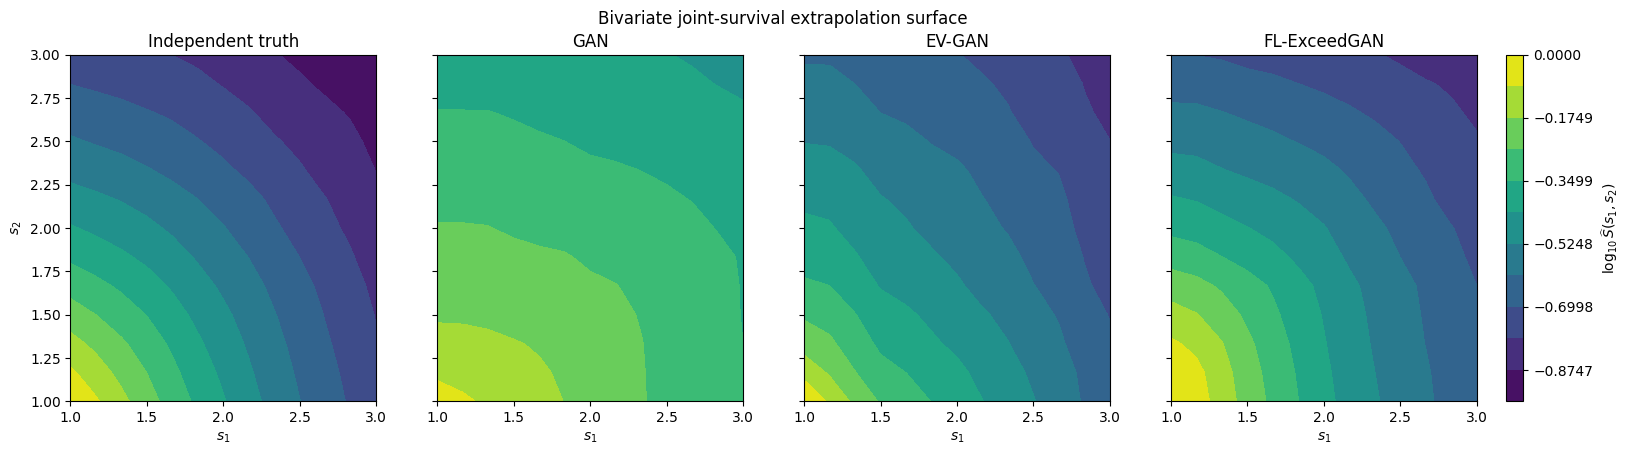

In [24]:
surfaces = [
    ("Independent truth", surface_truth),
    ("GAN", surface_gan),
    ("EV-GAN", surface_evgan),
    ("FL-ExceedGAN", surface_exceed)
]

positive_truth = surface_truth[surface_truth > 0]
floor_prob = positive_truth.min() if len(positive_truth) > 0 else 1e-6

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5), sharex=True, sharey=True)
levels = np.linspace(np.log10(max(floor_prob, 1e-6)), 0, 12)

for ax, (name, surface) in zip(axes, surfaces):
    Z = np.log10(np.maximum(surface, max(floor_prob, 1e-6)))
    contour = ax.contourf(scale_grid, scale_grid, Z.T, levels=levels)
    ax.set_xlabel(r"$s_1$")
    ax.set_title(name)

axes[0].set_ylabel(r"$s_2$")
fig.colorbar(contour, ax=axes, label=r"$\log_{10}\widehat S(s_1,s_2)$", fraction=0.025, pad=0.02)
fig.suptitle("Bivariate joint-survival extrapolation surface")
plt.show()

### Reading the extrapolation diagnostics

A useful fitted model should reproduce all three aspects simultaneously: overall dependence, the angular distribution of the most extreme excesses, and the decay of rare joint survivor probabilities. The `RMSE log10 joint survival` summarizes multiplicative error over the two-dimensional extrapolation surface; an error of 1 on this scale corresponds roughly to one order of magnitude.

# 17. Loss traces

The repository does not use these traces for checkpoint selection. They are plotted here only as diagnostics, using the losses printed every `VERBOSE` epochs.

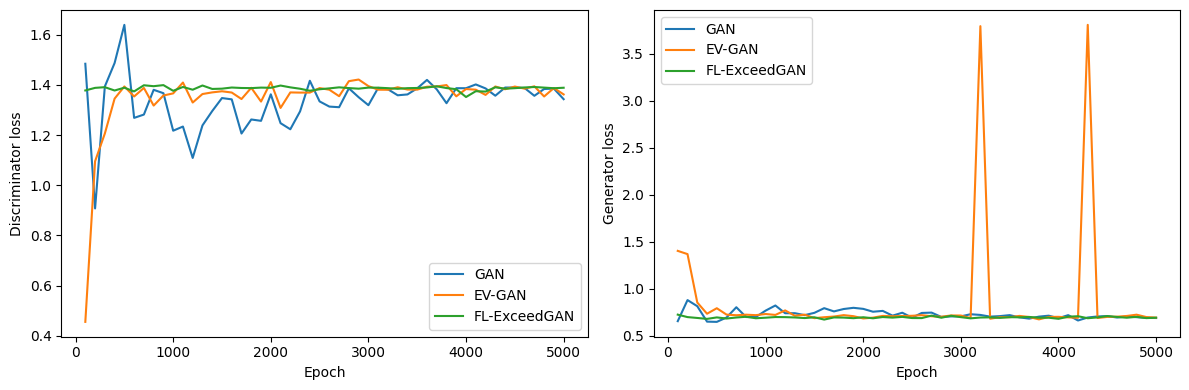

In [25]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

for name, model in [
    ("GAN", model_gan),
    ("EV-GAN", model_evgan),
    ("FL-ExceedGAN", model_exceed)
]:

    axes[0].plot(
        model.history_epoch,
        model.history_D,
        label=name
    )

    axes[1].plot(
        model.history_epoch,
        model.history_G,
        label=name
    )

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Discriminator loss")
axes[0].legend()

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Generator loss")
axes[1].legend()

plt.tight_layout()
plt.show()